# Random Forest Test

In [6]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
import pandas as pd
from sklearn.model_selection import train_test_split
import re
from sklearn.ensemble import RandomForestClassifier
from nltk.corpus import stopwords
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import numpy as np

# Functions

In [7]:
def clean_first_word(s):
    #Regex for cleaning title statement
    return re.sub(r'^\x98(\S+)\x9c', r'\1', s)

In [8]:
#Load Data
df_remove_na = pd.read_csv('data/converted_data/b3_not_na', sep=';')

In [12]:
df_remove_na.head()

,Unnamed: 0,ISBN,Language Code,Author,Title,Title Statement,Place,Publisher,Date,Number of Pages,Content Type,rvk Classification,gnd Topical Term,gnd Genre
0,6,3463008386,ger,"Kunze, Michael",NaN,Straße ins Feuer vom Leben und Sterben in der ...,München,Kindler,1982,397 S.,txt,"GN 9999, LC 41005, NS 4470","Strafrecht, Hexenprozess",Fiktionale Darstellung
1,7,NaN,ger,"Leppmann, Wolfgang",NaN,Goethe und die Deutschen d. Nachruhm e. Dichte...,Bern ; München,Scherz,1982,318 S.,txt,"GK 4291, GK 4351",Rezeption,Biografie
2,24,3515035400,ger,"Dorsch, Volker",NaN,Die Handelskammern der Rheinprovinz in der z...,Wiesbaden,Steiner,1982,"IX, 199 S.",txt,"NR 3450, NW 3150",Handelskammer,Hochschulschrift
3,27,3880731160,ger,"Volz, Ruprecht",NaN,Strindbergs Wanderungsdramen Studien zur Episi...,München,Tuduv-Verl.-Ges.,1982,187 S.,txt,GX 7283,Stationendrama,Hochschulschrift
4,29,3920190262,ger,NaN,NaN,Verhaltenstherapie in der Suchtkrankenhilfe Vo...,München,Röttger,1982,"V, 199 S.",txt,CU 8500,"Sozialtherapie, Sucht, Verhaltenstherapie, Suc...",Konferenzschrift


# Ranmom Forest

In [10]:
# Categories: Hochschulschrift, Aufsatzsammlung, Konferenzschrift, Fikltionale Darstellung, Biographie, Lehrbuch, Wörterbuch, Bibliographie, Kinderbuch, Jugendbuch

In [11]:
categories = ['Aufsatzsammlung', 'Bibliografie', 'Biografie', 'Fiktionale Darstellung', 'Hochschulschrift', 'Jugendbuch', 'Kinderbuch', 'Konferenzschrift', 'Lehrbuch', 'Wörterbuch']
df_categories = df_remove_na[df_remove_na["gnd Genre"].isin(categories)]
df_categories = df_categories.reset_index()

In [24]:
# Get German Records only
df_test = df_categories[df_categories['Language Code'] == 'ger']
X = df_test[["Language Code", "Publisher", "Place", "Title Statement", "Author", "gnd Topical Term"]].fillna("")
y = df_test['gnd Genre']
# Split Train Test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=67,
    stratify=y
)

In [25]:
# Set features
categorical_features = [
    "Language Code",
    #"Content Type"
]
numerical_features = [
    "Number of Pages",
    "Year"
]
text_features = [
    "gnd Topical Term",
    "Title Statement",
    "Publisher",
    "Place",
    "Author"
]
target = ["gnd Genre"]

In [26]:
# Get german stopwords
german_stop_words = stopwords.words('german')
# preprocess Tfidf + Tokenizer
preprocessor = ColumnTransformer(
    transformers=[
        ("title_tfidf", TfidfVectorizer(stop_words=german_stop_words, max_features=5000, ngram_range=(1, 2)),"Title Statement"),
        ("author_tfidf", TfidfVectorizer(max_features=5000),"Author"),
        ("topic_tfidf", TfidfVectorizer(max_features=5000),"gnd Topical Term"),
        ("place_tfidf", TfidfVectorizer(max_features=5000),"Place"),
        ("publisher_tfidf", TfidfVectorizer(max_features=5000),"Publisher"),
        #("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="")),
                       #  ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
       # ("num", SimpleImputer(strategy="median"), numeric_features)
    ]
)

In [27]:
# Set Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=67,
    n_jobs=-1,
    class_weight="balanced"
)
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)

In [28]:
# Fit model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('title_tfidf',
                                                  TfidfVectorizer(max_features=5000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words=['aber',
                                                                              'alle',
                                                                              'allem',
                                                                              'allen',
                                                                              'aller',
                                                                              'alles',
                                                                              'als',
                                                                              'also',
                                                                              'am',
                                                                              'an',
                                                                              'ander',
                                                                              'andere',
                                                                              'anderem',
                                                                              'anderen',
                                                                              'anderer',
                                                                              'anderes',
                                                                              'anderm',
                                                                              'andern',
                                                                              'anderr',
                                                                              'anders',
                                                                              'auch',
                                                                              'auf',
                                                                              'aus',
                                                                              'bei',
                                                                              'bin',
                                                                              'bis',
                                                                              'bist',
                                                                              '...
                                                 ('author_tfidf',
                                                  TfidfVectorizer(max_features=5000),
                                                  'Author'),
                                                 ('topic_tfidf',
                                                  TfidfVectorizer(max_features=5000),
                                                  'gnd Topical Term'),
                                                 ('place_tfidf',
                                                  TfidfVectorizer(max_features=5000),
                                                  'Place'),
                                                 ('publisher_tfidf',
                                                  TfidfVectorizer(max_features=5000),
                                                  'Publisher')])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=67))])

In [29]:
y_pred_test = model.predict(X_test)
accuracy_score(y_test, y_pred_test )

0.8831288139143018

In [30]:
# Get confusion Matrix
confusion_matrix(y_test, y_pred_test)

array([[30277,    52,   289,   457,  4028,    13,    22,  1299,   293,
           50],
       [  169,  2080,    38,    24,   479,     0,     1,    37,    18,
           13],
       [  571,    30,  6501,   622,  1735,    15,    25,    57,    49,
           42],
       [  321,    33,   274, 15686,   826,    52,    75,    42,    21,
           23],
       [  705,   290,   404,   424, 97018,    12,    26,   232,   564,
          108],
       [   20,     2,    14,   234,    52,  1018,   155,     2,     1,
            2],
       [   24,     3,    10,   154,    74,    97,  1272,     2,     3,
            2],
       [ 5140,    40,    60,    57,  1232,     1,     8, 15303,    62,
           18],
       [  396,    22,    22,    48,   857,     6,     6,    28, 12327,
           41],
       [  205,    34,    33,    41,   377,     2,     4,    21,    81,
         4051]], dtype=int64)

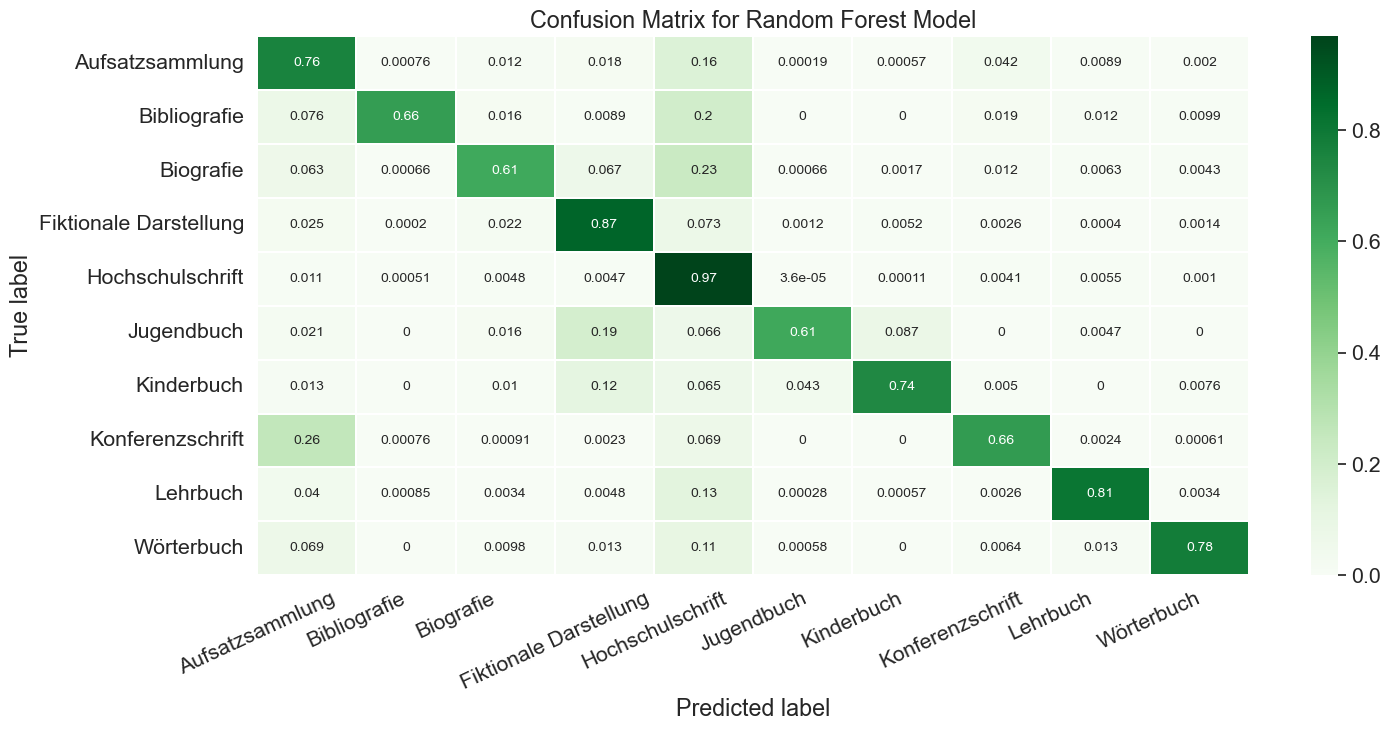

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
# Get and reshape confusion matrix data
matrix = confusion_matrix(y_test, y_pred_test)
matrix = matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]

# Build the plot
plt.figure(figsize=(16,7))
sns.set(font_scale=1.4)
sns.heatmap(matrix, annot=True, annot_kws={'size':10},
            cmap=plt.cm.Greens, linewidths=0.2)

# Add labels to the plot
tick_marks = np.arange(len(categories))
tick_marks2 = tick_marks + 0.5
plt.xticks(tick_marks, categories, rotation=25)
plt.yticks(tick_marks2, categories, rotation=0)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()

In [23]:
# get precision, recall, f1- score, Support
print(classification_report(y_test, y_pred_test))

                        precision    recall  f1-score   support

       Aufsatzsammlung       0.75      0.76      0.75     10590
          Bibliografie       0.95      0.66      0.78      1011
             Biografie       0.81      0.61      0.70      3008
Fiktionale Darstellung       0.86      0.87      0.86      5032
      Hochschulschrift       0.87      0.97      0.92     27674
            Jugendbuch       0.90      0.61      0.73       427
            Kinderbuch       0.79      0.74      0.76       397
      Konferenzschrift       0.87      0.66      0.75      6607
              Lehrbuch       0.90      0.81      0.85      3524
            Wörterbuch       0.93      0.78      0.85      1730

              accuracy                           0.85     60000
             macro avg       0.86      0.75      0.80     60000
          weighted avg       0.85      0.85      0.84     60000


In [270]:
pd.DataFrame(y_pred_test).value_counts()

0                     
Hochschulschrift          25017
Aufsatzsammlung           14953
Konferenzschrift           7498
Biografie                  3464
Fiktionale Darstellung     3394
Wörterbuch                 2067
Lehrbuch                   1608
Bibliografie               1493
Kinderbuch                  266
Jugendbuch                  240
Name: count, dtype: int64

# Testing on subsets

In [289]:
df_test = df_categories.head(30000)
X = df_test[["Language Code", "Publisher", "Place", "Title Statement", "Author", "gnd Topical Term"]].fillna("")
y = df_test['gnd Genre']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=67,
    stratify=y
)
test_rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=67,
    n_jobs=-1,
    class_weight="balanced"
)
test_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)
test_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('author_tfidf',
                                                  TfidfVectorizer(max_features=5000),
                                                  'Author'),
                                                 ('topic_tfidf',
                                                  TfidfVectorizer(max_features=5000),
                                                  'gnd Topical Term'),
                                                 ('place_tfidf',
                                                  TfidfVectorizer(max_features=5000),
                                                  'Place'),
                                                 ('publisher_tfidf',
                                                  TfidfVectorizer(max_features=5000),
                                                  'Publisher'),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Language Code'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=67))])

In [291]:
y_pred_test_test = test_model.predict(X_test)
print(classification_report(y_test, y_pred_test_test))

                        precision    recall  f1-score   support

       Aufsatzsammlung       0.54      0.66      0.59      1831
          Bibliografie       0.45      0.38      0.41       213
             Biografie       0.52      0.33      0.40       502
Fiktionale Darstellung       0.58      0.52      0.55       346
      Hochschulschrift       0.80      0.65      0.72      1997
            Jugendbuch       0.18      0.12      0.15        16
            Kinderbuch       0.50      0.42      0.46        26
      Konferenzschrift       0.43      0.51      0.47       899
              Lehrbuch       0.68      0.31      0.43        54
            Wörterbuch       0.24      0.40      0.30       116

              accuracy                           0.58      6000
             macro avg       0.49      0.43      0.45      6000
          weighted avg       0.60      0.58      0.58      6000


In [287]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, 
    X_test,
    y_test,
    n_repeats=10,
    random_state=67,
    n_jobs=-1,
    scoring="f1_macro"
)
feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

print(feature_importance)

            feature  importance
3   Title Statement    0.378127
1         Publisher    0.072719
0     Language Code    0.048867
2             Place    0.041303
5  gnd Topical Term    0.039139
4            Author    0.023540
